# HippocampusMR Registration Demo with NITorch

This notebook demonstrates **pairwise medical image registration** using the [NITorch](https://github.com/balbasty/nitorch) library on hippocampus MRI data from the [HippocampusMR dataset](https://cloud.imi.uni-luebeck.de/s/gPN6bzJ4xf7HzG8) (part of the [Learn2Reg](https://learn2reg.grand-challenge.org/) challenge).

## What This Notebook Does

1. **Loads a pair of hippocampus MRI scans** (fixed and moving images) along with their segmentation labels
2. **Visualizes the initial alignment** and computes baseline Dice scores between labels
3. **Runs registration with multiple loss functions** to compare their effectiveness:
   - **LCC** (Local Correlation Coefficient) - robust to local intensity variations
   - **Dice** - directly optimizes label overlap (requires segmentations)
   - **NMI** (Normalized Mutual Information) - handles different contrasts
   - **MSE** (Mean Squared Error) - assumes same contrast/intensity
4. **Evaluates registration quality** using Dice scores on the segmentation labels

## Registration Pipeline

The `nitorch register` command performs:
1. **Affine registration** - global linear alignment (translation, rotation, scaling, shearing)
2. **Nonlinear registration** - local deformations using Stationary Velocity Fields (SVF)
3. **Multi-resolution pyramid** - coarse-to-fine optimization for robustness

## Dataset Information

The HippocampusMR dataset consists of MRI acquired in 90 healthy adults and 105 adults with non-affective psychotic disorders. The MRI data shows parts of the brain covering the hippocampus formation. The algorithm targets the alignment of two neighboring small structures (hippocampus head and body) with high precision on mono-modal MRI images between different patients.

**Labels:**
- 0: Background
- 1: Hippocampus Head
- 2: Hippocampus Tail

## Requirements

- **HippocampusMR Dataset**: Download from [Learn2Reg](https://cloud.imi.uni-luebeck.de/s/xcZrLSQYtK68em8)
- **GPU**: CUDA-capable GPU recommended for faster registration
- **Dependencies**: In addition to `nitorch` do: `pip install nibabel numpy matplotlib nvidia-ml-py`

## Open Issues

- The `[tukey, cc, gmm, lgmm, emmi, cat]` losses seem not to work, ie, either loss behaves erratically or error is thrown during registration.

In [1]:
import os
import json
import warnings
import random
import numpy as np
import torch

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Suppress FutureWarnings from interpol package (PyTorch AMP deprecation warnings)
warnings.filterwarnings("ignore", category=FutureWarning, module="interpol")
# Also suppress in subprocesses (nitorch CLI commands)
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

In [2]:
# Import helper functions from demo_helpers module
from demo_helpers import (
    add_loss,
    compute_dice_scores,
    create_displacement_field,
    get_pair,
    get_subject_id,
    register,
    resize_pair,
    reslice,
    visualize_dice_scores,
    visualize_pair,
)

In [3]:
# Parameters
# dir_data: Root directory containing the HippocampusMR dataset with 'imagesTr' and 'labelsTr'
#           subfolders. Download from: https://cloud.imi.uni-luebeck.de/s/gPN6bzJ4xf7HzG8
# dir_out:  Output directory where registration results will be saved. A subfolder
#           will be created for each fixed-moving pair.
# json_meta: Path to the dataset JSON file containing registration pair definitions.
# id_pair:  Index of the image pair to register (0-indexed). The HippocampusMR validation
#           set contains 60 pairs (indices 0-59).
# resize_factor: Downsampling factor for faster testing.
#           - 0 or 1: No resizing, use original images (64³ for HippocampusMR)
#           - 2: Half resolution (32³), ~8x faster
#           - 4: Quarter resolution (16³), ~64x faster
# use_gpu:  Whether to use GPU for registration (faster) or CPU.
dir_data = "/home/mbrudfors/Data/Learn2Reg/HippocampusMR"
dir_out = "/home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered"
os.makedirs(dir_out, exist_ok=True)
json_meta = os.path.join(dir_data, "HippocampusMR_dataset.json")
id_pair = 0
resize_factor = 3  # Set to >1 for quicker testing
use_gpu = False  # Set to False to run on CPU

In [4]:
# Read dataset metadata
with open(json_meta, 'r') as f:
    meta = json.load(f)
    
# Get pair
print(f"Getting pair {id_pair + 1} of {len(meta['registration_val'])}")
pair = get_pair(meta, id_pair, dir_data, verbose=True)

# Create unique subfolder for this fixed-moving pair
pair["fixed"]["id"] = get_subject_id(pair["fixed"]["image"])
pair["moving"]["id"] = get_subject_id(pair["moving"]["image"])
suffix = f"_resized_f{resize_factor}" if resize_factor not in [0, 1] else ""
pair["dir_out"] = os.path.join(dir_out, f"{pair['fixed']['id']}_to_{pair['moving']['id']}{suffix}")
os.makedirs(pair["dir_out"], exist_ok=True)
print(f"\nOutput directory: {pair['dir_out']}")

# Resize images if requested (for quick testing)
pair = resize_pair(pair, factor=resize_factor, verbose=True, use_gpu=use_gpu)

Getting pair 1 of 60

FIXED:
  Image: /home/mbrudfors/Data/Learn2Reg/HippocampusMR/imagesTr/HippocampusMR_0201_0000.nii.gz
    Shape: (64, 64, 64)
    Dtype: float64
    Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Label: /home/mbrudfors/Data/Learn2Reg/HippocampusMR/labelsTr/HippocampusMR_0201_0000.nii.gz
    Shape: (64, 64, 64)
    Dtype: float64
    Num. labels: 3
    Label values: [np.int64(0), np.int64(1), np.int64(2)]
MOVING:
  Image: /home/mbrudfors/Data/Learn2Reg/HippocampusMR/imagesTr/HippocampusMR_0260_0000.nii.gz
    Shape: (64, 64, 64)
    Dtype: float64
    Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Label: /home/mbrudfors/Data/Learn2Reg/HippocampusMR/labelsTr/HippocampusMR_0260_0000.nii.gz
    Shape: (64, 64, 64)
    Dtype: float64
    Num. labels: 3
    Label values: [np.int64(0), np.int64(1), np.int64(2)]

Output directory: /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f

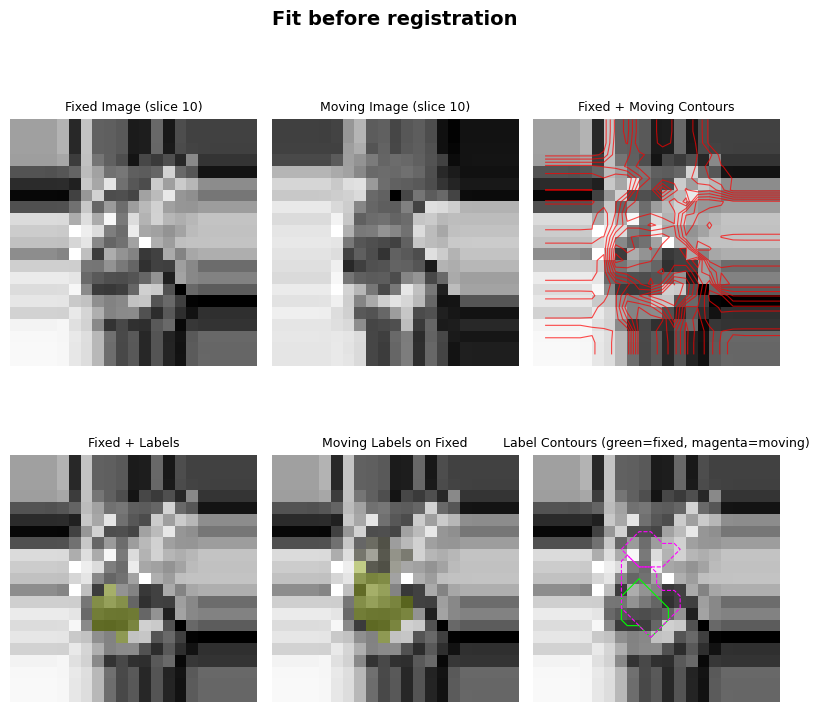

In [5]:
# Visualize the pair before registration
visualize_pair(
    fixed_image=pair["fixed"]["image"],
    moving_image=pair["moving"]["image"],
    fixed_label=pair["fixed"]["label"],
    moving_label=pair["moving"]["label"],
    title="Fit before registration",
);


Mean dice score: 0.532860


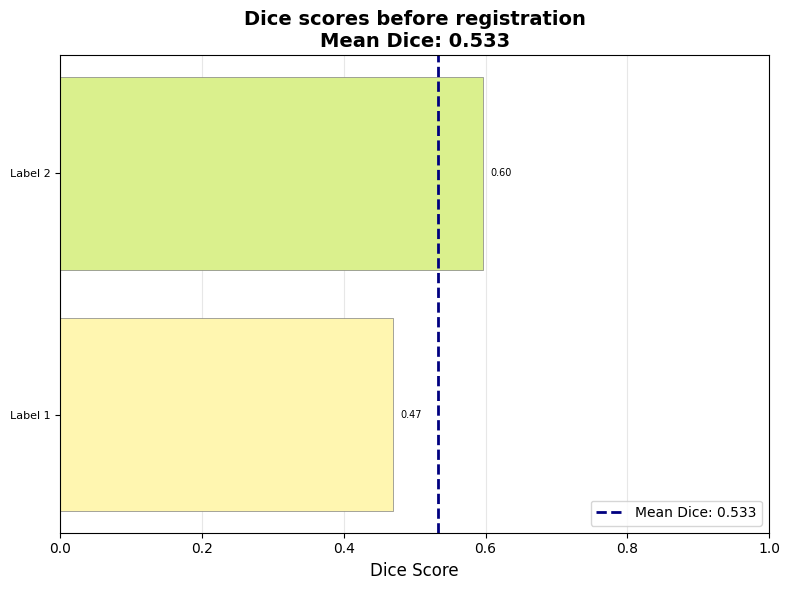

In [6]:
# Compute and visualize Dice scores before registration
dice_scores, mean_dice = compute_dice_scores(
    pair["fixed"]["label"], 
    pair["moving"]["label"]
)
visualize_dice_scores(dice_scores, mean_dice, title="Dice scores before registration");

### Nitorch registration losses

The `nitorch register` CLI supports the following loss functions:

| Name | Aliases | Description |
|------|---------|-------------|
| `mi` | `nmi` | **Mutual Information** (can be normalized) - for images with different contrasts |
| `mse` | `l2` | **Mean Squared Error** - for images with the same contrast |
| `mad` | `l1` | **Median Absolute Deviation** - robust L1 loss |
| `tuk` | `tukey` | **Tukey's Biweight** - truncated L2 loss for robustness |
| `cc` | `ncc` | **Correlation Coefficient** (Normalized Cross Correlation) |
| `lcc` | `lncc` | **Local Correlation Coefficient** - spatially-varying NCC |
| `gmm` | - | **Gaussian Mixture Model** likelihood |
| `lgmm` | - | **Local GMM** - spatially-varying GMM |
| `emmi` | - | **EM-based Mutual Information** |
| `cat` | `cce` | **Categorical Cross-Entropy** - for soft segmentations |
| `dice` | `f1` | **Dice Coefficient** - for label maps |

#### Common use cases
- **Same contrast images**: `mse`, `cc`, `lcc`
- **Different contrast images**: `mi`, `gmm`, `lgmm`, `emmi`
- **Label/segmentation maps**: `dice`, `cat`
- **Robust to outliers**: `mad`, `tuk`

In [7]:
# Nitorch LCC registration
loss = "lcc"
# Add outputs from registration loss to pair dictionary
pair = add_loss(pair, loss)
# Run registration
register(loss, pair, use_gpu=use_gpu)
# Create displacement field and add to pair dictionary
pair = create_displacement_field(pair, loss, use_gpu=use_gpu)

   AFFINE
--------------------------------------------------------------------------
   PYRAMID LEVEL 2
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 002 |     -1.40078 +            0 =     -1.40078 |  0.000284195
--------------------------------------------------------------------------
   PYRAMID LEVEL 1
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 010 |     -1.35968 +            0 =     -1.35968 |   3.5882e-05
--------------------------------------------------------------------------
   PYRAMID LEVEL 0
--------------------------------------------------------------------------
step     | it  |     fit      +  

Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0260_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/lcc/HippocampusMR_0260_0000.label.resized_f3.label.moved.nii.gz
Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0201_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/lcc/HippocampusMR_0201_0000.label.resized_f3.label.moved.nii.gz

LCC loss mean dice score: 0.739329


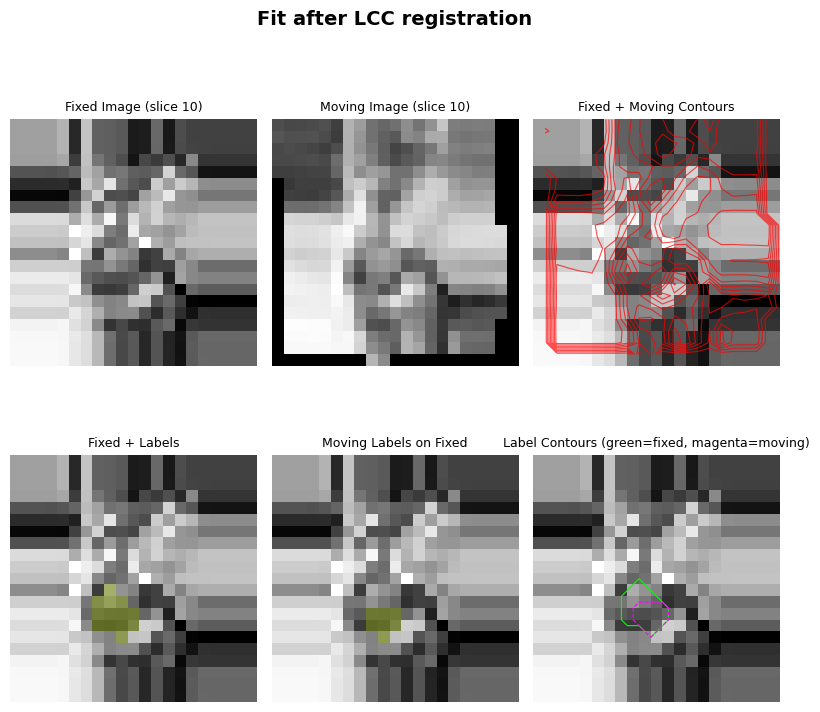

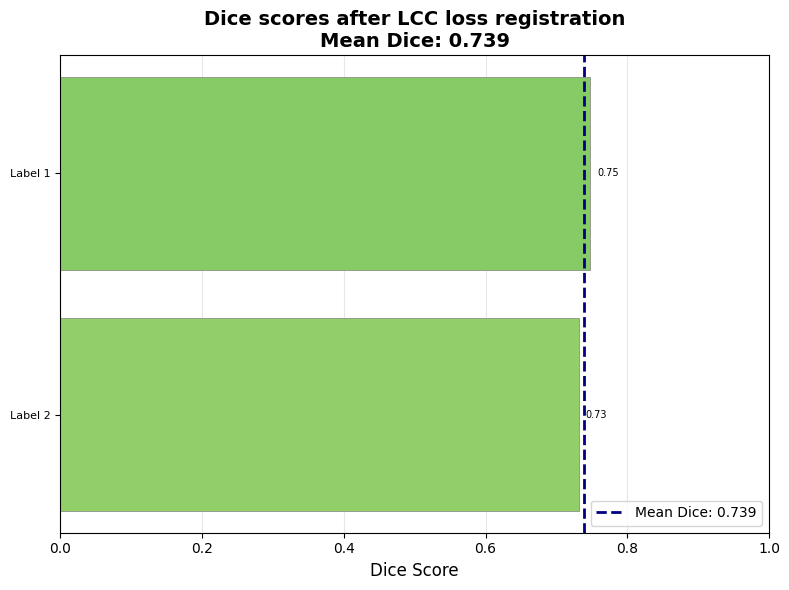

In [8]:
# Reslice registration results
reslice(pair, loss, use_gpu=use_gpu)
# Visualize registration results
visualize_pair(
    fixed_image=pair["fixed"]["image"],
    moving_image=pair["loss"][loss]["moving"]["image"],
    fixed_label=pair["fixed"]["label"],
    moving_label=pair["loss"][loss]["moving"]["label"],
    title=f"Fit after {loss.upper()} registration",
)
# Compute and visualize Dice scores
dice_scores, mean_dice = compute_dice_scores(
    pair["fixed"]["label"], 
    pair["loss"][loss]["moving"]["label"],
    loss=loss,
)
visualize_dice_scores(dice_scores, mean_dice, title=f"Dice scores after {loss.upper()} loss registration");

In [9]:
# Nitorch Dice registration
loss = "dice"
# Add outputs from registration loss to pair dictionary
pair = add_loss(pair, loss)
# Run registration
register(loss, pair, use_gpu=use_gpu)
# Create displacement field and add to pair dictionary
pair = create_displacement_field(pair, loss, use_gpu=use_gpu)

   AFFINE
--------------------------------------------------------------------------
   PYRAMID LEVEL 2
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 006 |     0.219259 +            0 =     0.219259 |  0.000915468
--------------------------------------------------------------------------
   PYRAMID LEVEL 1
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 007 |      0.13527 +            0 =      0.13527 |  0.000249505
--------------------------------------------------------------------------
   PYRAMID LEVEL 0
--------------------------------------------------------------------------
step     | it  |     fit      +  

Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0260_0000.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/dice/HippocampusMR_0260_0000.resized_f3.image.moved.nii.gz
Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0201_0000.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/dice/HippocampusMR_0201_0000.resized_f3.image.moved.nii.gz

DICE loss mean dice score: 0.979994


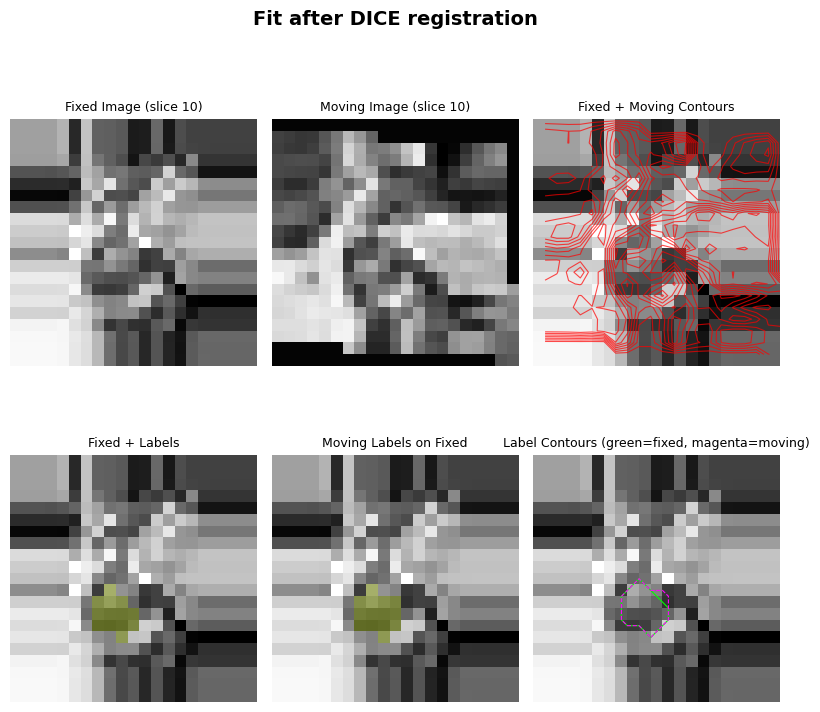

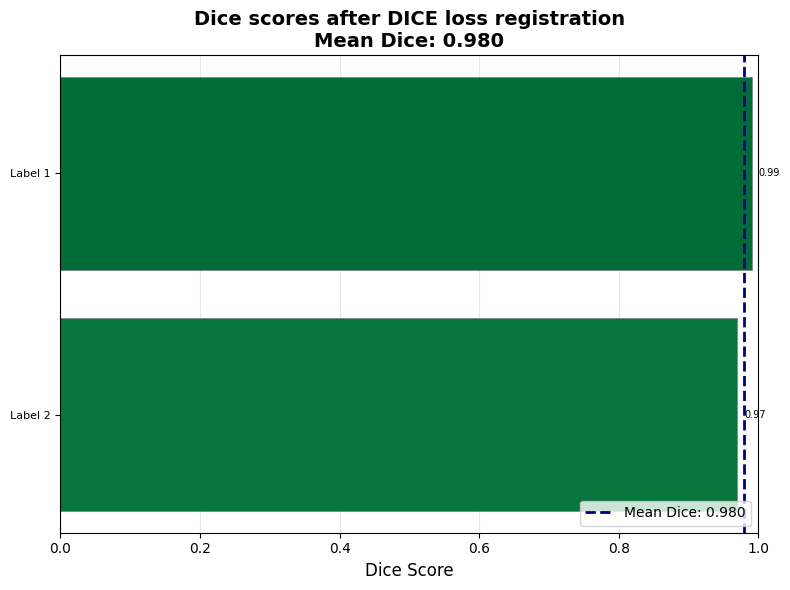

In [10]:
# Reslice registration results
reslice(pair, loss, use_gpu=use_gpu)
# Visualize registration results
visualize_pair(
    fixed_image=pair["fixed"]["image"],
    moving_image=pair["loss"][loss]["moving"]["image"],
    fixed_label=pair["fixed"]["label"],
    moving_label=pair["loss"][loss]["moving"]["label"],
    title=f"Fit after {loss.upper()} registration",
)
# Compute and visualize Dice scores
dice_scores, mean_dice = compute_dice_scores(
    pair["fixed"]["label"], 
    pair["loss"][loss]["moving"]["label"],
    loss=loss,
)
visualize_dice_scores(dice_scores, mean_dice, title=f"Dice scores after {loss.upper()} loss registration");

In [11]:
# Nitorch NMI registration
loss = "nmi"
# Add outputs from registration loss to pair dictionary
pair = add_loss(pair, loss)
# Run registration
register(loss, pair, use_gpu=use_gpu)
# Create displacement field and add to pair dictionary
pair = create_displacement_field(pair, loss, use_gpu=use_gpu)

   AFFINE
--------------------------------------------------------------------------
   PYRAMID LEVEL 2
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 005 |     0.817877 +            0 =     0.817877 |  6.42538e-05
--------------------------------------------------------------------------
   PYRAMID LEVEL 1
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 002 |     0.884993 +            0 =     0.884993 |  0.000906467
--------------------------------------------------------------------------
   PYRAMID LEVEL 0
--------------------------------------------------------------------------
step     | it  |     fit      +  

Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0260_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/nmi/HippocampusMR_0260_0000.label.resized_f3.label.moved.nii.gz
Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0201_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/nmi/HippocampusMR_0201_0000.label.resized_f3.label.moved.nii.gz

NMI loss mean dice score: 0.714330


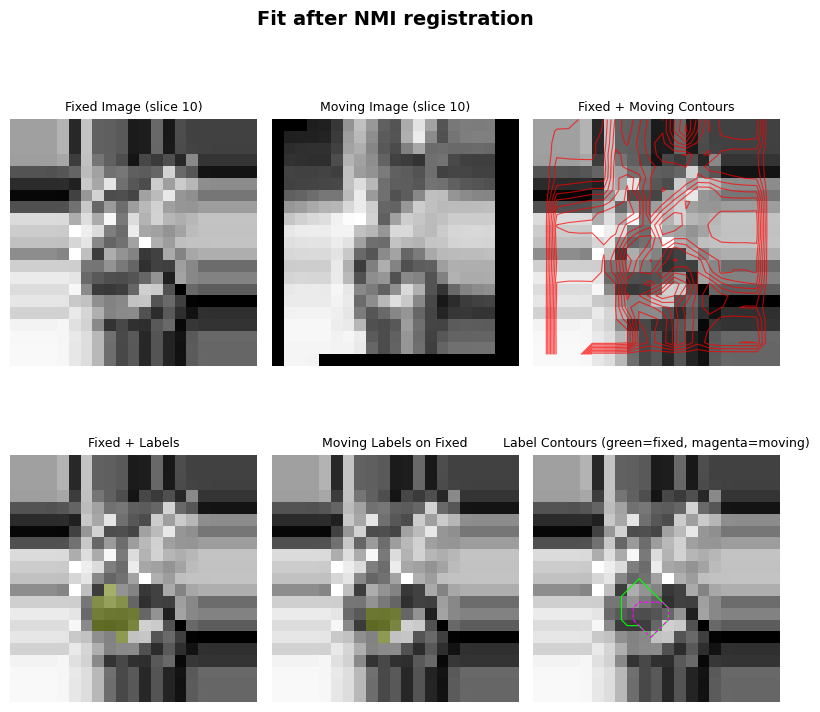

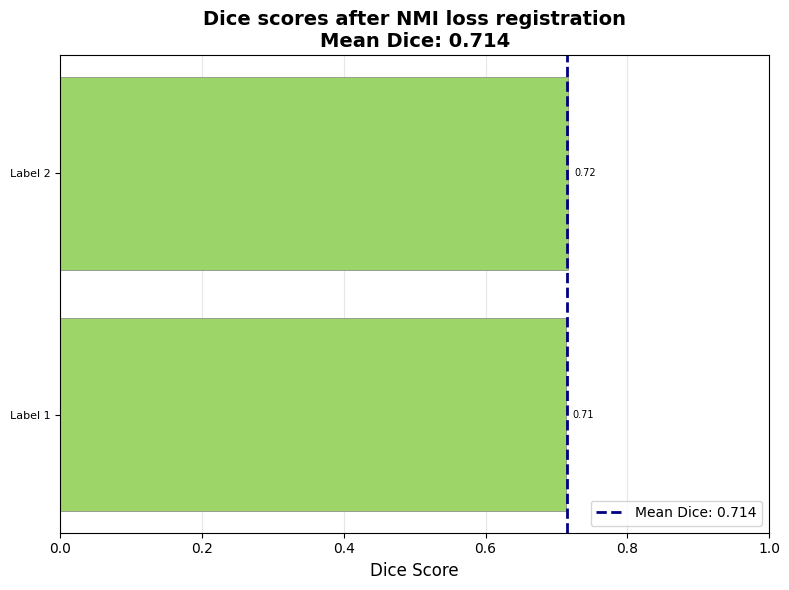

In [12]:
# Reslice registration results
reslice(pair, loss, use_gpu=use_gpu)
# Visualize registration results
visualize_pair(
    fixed_image=pair["fixed"]["image"],
    moving_image=pair["loss"][loss]["moving"]["image"],
    fixed_label=pair["fixed"]["label"],
    moving_label=pair["loss"][loss]["moving"]["label"],
    title=f"Fit after {loss.upper()} registration",
)
# Compute and visualize Dice scores
dice_scores, mean_dice = compute_dice_scores(
    pair["fixed"]["label"], 
    pair["loss"][loss]["moving"]["label"],
    loss=loss,
)
visualize_dice_scores(dice_scores, mean_dice, title=f"Dice scores after {loss.upper()} loss registration");

In [13]:
# Nitorch MSE registration
loss = "mse"
# Add outputs from registration loss to pair dictionary
pair = add_loss(pair, loss)
# Run registration
register(loss, pair, use_gpu=use_gpu)
# Create displacement field and add to pair dictionary
pair = create_displacement_field(pair, loss, use_gpu=use_gpu)

   AFFINE
--------------------------------------------------------------------------
   PYRAMID LEVEL 2
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 005 |     -1.96122 +            0 =     -1.96122 |  0.000740767
--------------------------------------------------------------------------
   PYRAMID LEVEL 1
--------------------------------------------------------------------------
step     | it  |     fit      +    affine    =     obj      |     gain    
--------------------------------------------------------------------------
(affine) | 004 |     -1.59857 +            0 =     -1.59857 |  0.000347853
--------------------------------------------------------------------------
   PYRAMID LEVEL 0
--------------------------------------------------------------------------
step     | it  |     fit      +  

Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0260_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/mse/HippocampusMR_0260_0000.label.resized_f3.label.moved.nii.gz
Reslicing:   /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/resized/HippocampusMR_0201_0000.label.resized_f3.nii.gz
          -> /home/mbrudfors/Data/Learn2Reg/HippocampusMR_registered/HippocampusMR_0201_to_HippocampusMR_0260_resized_f3/mse/HippocampusMR_0201_0000.label.resized_f3.label.moved.nii.gz

MSE loss mean dice score: 0.707343


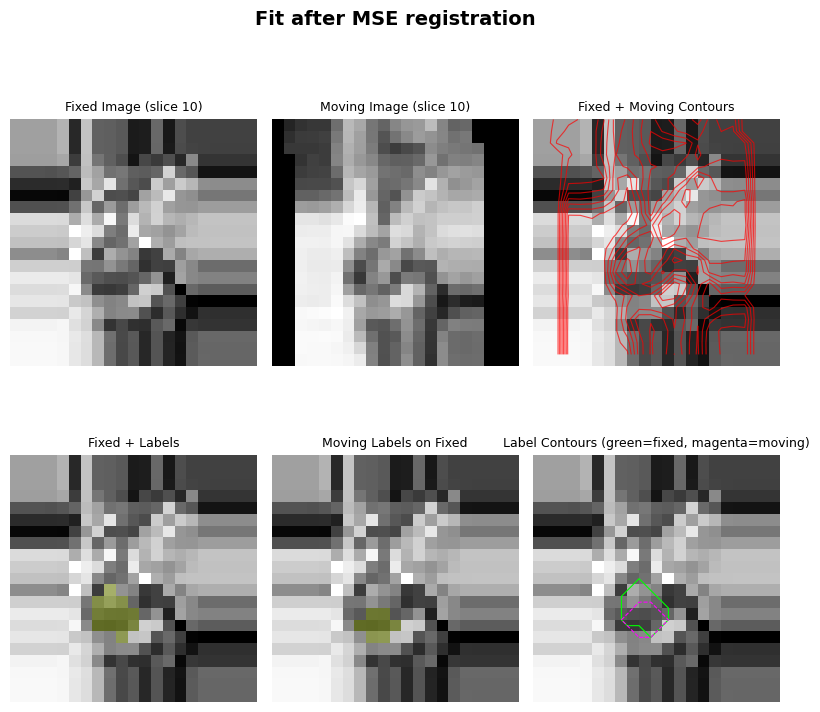

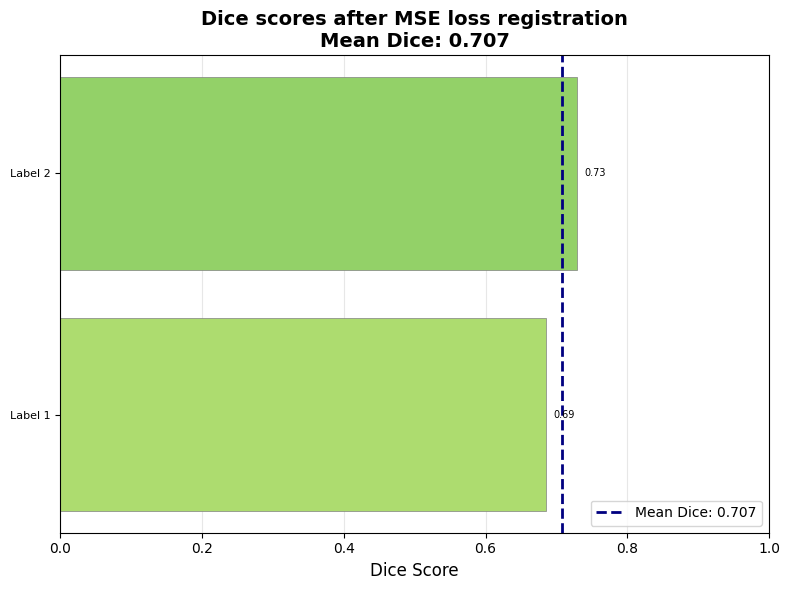

In [14]:
# Reslice registration results
reslice(pair, loss, use_gpu=use_gpu)
# Visualize registration results
visualize_pair(
    fixed_image=pair["fixed"]["image"],
    moving_image=pair["loss"][loss]["moving"]["image"],
    fixed_label=pair["fixed"]["label"],
    moving_label=pair["loss"][loss]["moving"]["label"],
    title=f"Fit after {loss.upper()} registration",
)
# Compute and visualize Dice scores
dice_scores, mean_dice = compute_dice_scores(
    pair["fixed"]["label"], 
    pair["loss"][loss]["moving"]["label"],
    loss=loss,
)
visualize_dice_scores(dice_scores, mean_dice, title=f"Dice scores after {loss.upper()} loss registration");